In [ ]:
!pip install tensorflow=='2.15' --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 6.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorstore 0.1.67 requires ml-dtypes>=0.3.1, but you have ml-dtypes 0.2.0 which is incompatible.
tf-keras 2.17.0 requires tensorflow<2.18,>=2.17, but you have tensorflow 2.15.0 which is incompatible.


## Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import numpy as np
import glob
import cv2

from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Prepare Data

In [ ]:
!cp "/content/gdrive/MyDrive/DATABASES/iqa_spoof_dataset/fas_iqa_dataset.zip" .
!unzip -qq fas_iqa_dataset.zip

In [ ]:
np.random.seed(42)

In [ ]:
df = pd.DataFrame([
    {
        'filename': x.split('/')[-1],
        'scene': x.split('/')[-2],
        'label': x.split('/')[-3],
        'data_type': x.split('/')[-4],
        'distortion_type': x.split('/')[-5],
        'label_iqa': x.split('/')[-1].split('_f_')[0] if len(x.split('/')[-1].split('_f_'))>1 else 'original',
        'full_path_iqa': x,
    } for x in glob.glob('fas_iqa_dataset/*/*/*/*/*')
])
print('Size DF:', df.shape[0])
df.sample(3)

Size DF: 100000


,filename,scene,label,data_type,distortion_type,label_iqa,full_path_iqa
75721,noise_15_f_frame_16.jpg,attack_client021_laptop_SD_iphone_video_scene01,attack,train,noise,noise_15,fas_iqa_dataset/noise/train/attack/attack_clie...
80184,noise_45_f_227439.jpg,client004692_Env0_Ilum0_Spt0,real,train,noise,noise_45,fas_iqa_dataset/noise/train/real/client004692_...
19864,BlurY_7_f_459116.jpg,client004367_Env1_Ilum1_Spt7,real,train,BlurY,BlurY_7,fas_iqa_dataset/BlurY/train/real/client004367_...


<Axes: xlabel='label_iqa'>

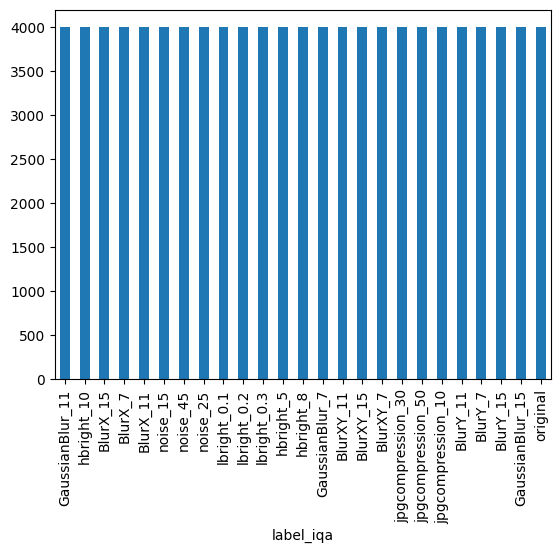

In [ ]:
df['label_iqa'].value_counts().plot.bar()

In [ ]:
df.data_type.value_counts()

,count
data_type,
train,85000
test,15000


In [ ]:
train = df[df.data_type=='train']
val = df[df.data_type=='test']
train.shape, val.shape

((85000, 7), (15000, 7))

## Prepare Generators

In [ ]:
train_datagen = ImageDataGenerator(
    # brightness_range=[0.4, 1.4],
    rescale=1./255,
    # rotation_range=45,
    # zoom_range=0.2,
    # horizontal_flip=True,
    vertical_flip=True,
)

val_datagen = ImageDataGenerator(rescale=1./255)

# test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
df.label_iqa.nunique()

25

In [ ]:
NUM_CLASS_IQA = df.label_iqa.nunique()
WIDTH = 256
HEIGHT = 256
INPUT_SIZE = [WIDTH, HEIGHT, 3]
IMG_SIZE = (HEIGHT, WIDTH)
BATCH_SIZE = 128

NUM_CLASS_IQA

25

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    train,
    '',
    x_col='full_path_iqa',
    y_col='label_iqa',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE
)

Found 85000 validated image filenames belonging to 25 classes.


In [ ]:
val_generator = val_datagen.flow_from_dataframe(
    val,
    '',
    x_col='full_path_iqa',
    y_col='label_iqa',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 15000 validated image filenames belonging to 25 classes.


## Prepare Model

In [ ]:
from tensorflow.keras.applications import MobileNetV2

In [ ]:
from tensorflow.keras.layers import *
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

In [ ]:
def iqa_mbnv2_model(input_shape):
    base_model_mobilenet = MobileNetV2(weights='imagenet', include_top=False,
                         input_shape=input_shape)

    input_x = base_model_mobilenet.output
    x = GlobalAveragePooling2D()(input_x)
    x = Dense(512, activation='relu', kernel_initializer='he_uniform')(x)
    x = BatchNormalization()(x)
    x = Dropout(.1)(x)
    iqa_output = Dense(NUM_CLASS_IQA, activation='softmax', name='iqa_class')(x) # activation='softmax'

    model = Model(base_model_mobilenet.input, iqa_output)

    return model

In [ ]:
model = iqa_mbnv2_model(INPUT_SIZE)

9406464/9406464 [==============================] - 1s 0us/step


In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss=tf.keras.losses.categorical_crossentropy,
              metrics=['accuracy'], optimizer=optimizer)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [ ]:
earlystop_callback = EarlyStopping(patience=6)

learning_rate_reduction_callback = ReduceLROnPlateau(monitor='val_loss',
                                            patience=3,
                                            verbose=1,
                                            factor=0.2,
                                            min_lr=1e-8)

mcp_save_callback = ModelCheckpoint(
    '/content/models/save_model_mblnet_vL{val_loss}.keras',
    save_best_only=True, monitor='val_loss', mode='min', verbose=1)

callbacks_list = [earlystop_callback, learning_rate_reduction_callback, mcp_save_callback]

In [ ]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 128, 128, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 128, 128, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 128, 128, 32)         0         ['bn_Conv1[0][0]']        

## Train Model

In [ ]:
train.shape[0]//BATCH_SIZE, val.shape[0]//BATCH_SIZE

(664, 117)

In [ ]:
steps_per_epoch =  train.shape[0]//BATCH_SIZE#+1*(train.shape[0]%BATCH_SIZE!=0)
validation_steps =  val.shape[0]//BATCH_SIZE#+1*(val.shape[0]%BATCH_SIZE!=0)

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    validation_steps=validation_steps,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks_list
)

Epoch 1/30
664/664 [==============================] - ETA: 0s - loss: 0.4107 - accuracy: 0.8440
Epoch 1: val_loss improved from inf to 7.40061, saving model to /content/models/save_model_mblnet_vL7.400606155395508.keras
664/664 [==============================] - 479s 674ms/step - loss: 0.4107 - accuracy: 0.8440 - val_loss: 7.4006 - val_accuracy: 0.1980 - lr: 0.0010
Epoch 2/30
664/664 [==============================] - ETA: 0s - loss: 0.1924 - accuracy: 0.9256
Epoch 2: val_loss improved from 7.40061 to 6.18430, saving model to /content/models/save_model_mblnet_vL6.18430233001709.keras
664/664 [==============================] - 447s 672ms/step - loss: 0.1924 - accuracy: 0.9256 - val_loss: 6.1843 - val_accuracy: 0.3072 - lr: 0.0010
Epoch 3/30
664/664 [==============================] - ETA: 0s - loss: 0.1858 - accuracy: 0.9306
Epoch 3: val_loss did not improve from 6.18430
664/664 [==============================] - 447s 672ms/step - loss: 0.1858 - accuracy: 0.9306 - val_loss: 7.3776 - val_

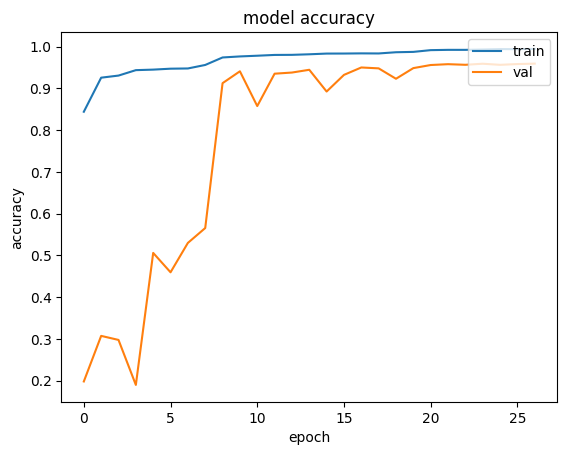

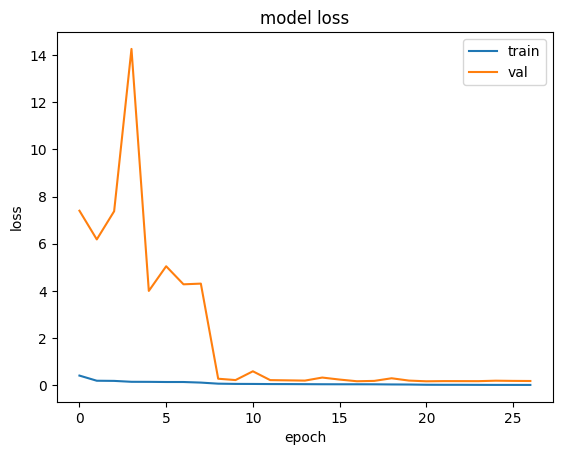

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

## Save Model

In [ ]:
model.save('[PhD_IQA][FAS-IQA]MobileNetV2.keras')
!cp "[PhD_IQA][FAS-IQA]MobileNetV2.keras" "/content/gdrive/MyDrive/PhD_Models/saved_model/phd_model_iqa/"

## Evaluate Model

In [ ]:
test_generator = val_datagen.flow_from_dataframe(
    val,
    '',
    x_col='full_path_iqa',
    y_col='label_iqa',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 15000 validated image filenames belonging to 25 classes.


In [ ]:
steps_test = val.shape[0]//BATCH_SIZE+1*(val.shape[0]%BATCH_SIZE!=0)
steps_test

118

In [ ]:
predictions = model.predict(test_generator,steps=steps_test,verbose=1)

118/118 [==============================] - 35s 291ms/step


In [ ]:
class_dict = {v:k for k,v in test_generator.class_indices.items()}
# class_dict = {idx:v for idx, v in enumerate(val.label_iqa.unique())}
class_dict

{0: 'BlurXY_11',
 1: 'BlurXY_15',
 2: 'BlurXY_7',
 3: 'BlurX_11',
 4: 'BlurX_15',
 5: 'BlurX_7',
 6: 'BlurY_11',
 7: 'BlurY_15',
 8: 'BlurY_7',
 9: 'GaussianBlur_11',
 10: 'GaussianBlur_15',
 11: 'GaussianBlur_7',
 12: 'hbright_10',
 13: 'hbright_5',
 14: 'hbright_8',
 15: 'jpgcompression_10',
 16: 'jpgcompression_30',
 17: 'jpgcompression_50',
 18: 'lbright_0.1',
 19: 'lbright_0.2',
 20: 'lbright_0.3',
 21: 'noise_15',
 22: 'noise_25',
 23: 'noise_45',
 24: 'original'}

In [ ]:
# val = val.reset_index(drop=True)
val['label_pred'] = np.argmax(predictions, axis=1).tolist()
val['label_pred'] = val['label_pred'].replace(class_dict)
val['label_pred_proba_max'] = np.max(predictions, axis=1).tolist()
val['label_pred_proba'] = predictions.tolist()

val.head(3)

<ipython-input-33-c296783cc164>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['label_pred'] = np.argmax(predictions, axis=1).tolist()
<ipython-input-33-c296783cc164>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['label_pred'] = val['label_pred'].replace(class_dict)
<ipython-input-33-c296783cc164>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pa

,filename,scene,label,data_type,distortion_type,label_iqa,full_path_iqa,label_pred,label_pred_proba_max,label_pred_proba
0,noise_15_f_frame_203.jpg,attack_client032_laptop_SD_iphone_video_scene01,attack,test,noise,noise_15,fas_iqa_dataset/noise/test/attack/attack_clien...,noise_15,0.999989,"[3.494824707406252e-10, 4.821964161294545e-09,..."
1,noise_45_f_frame_203.jpg,attack_client032_laptop_SD_iphone_video_scene01,attack,test,noise,noise_45,fas_iqa_dataset/noise/test/attack/attack_clien...,noise_45,0.999341,"[2.4168602976715192e-06, 1.4050658592168475e-0..."
2,noise_25_f_frame_203.jpg,attack_client032_laptop_SD_iphone_video_scene01,attack,test,noise,noise_25,fas_iqa_dataset/noise/test/attack/attack_clien...,noise_25,0.999998,"[2.762560735725117e-10, 2.6738722347374733e-09..."


In [ ]:
val.to_csv("/content/gdrive/MyDrive/PhD_Models/saved_model/phd_model_iqa/mobilenetv2_validation.csv", index=False)

In [ ]:
f1_score(val.label_iqa, val.label_pred, average='weighted')

0.9590397660093569

In [ ]:
accuracy_score(val.label_iqa, val.label_pred)

0.9592

<Axes: xlabel='label_pred'>

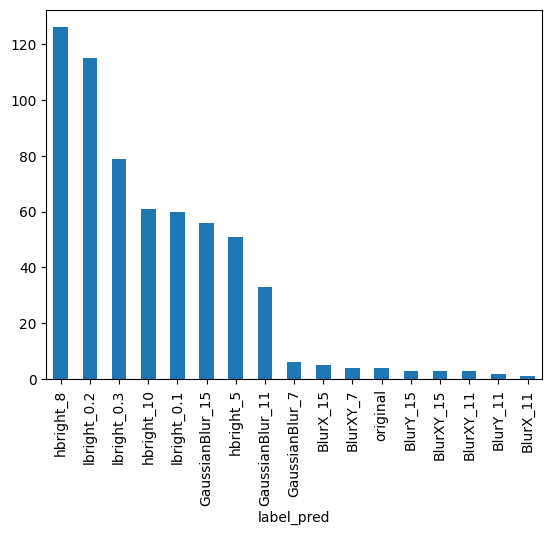

In [ ]:
val[val.label_iqa!=val.label_pred].label_pred.value_counts().plot.bar()

In [ ]:
cf_matrix = confusion_matrix(val.label_iqa.tolist(), val.label_pred.tolist())

In [ ]:
import seaborn as sns

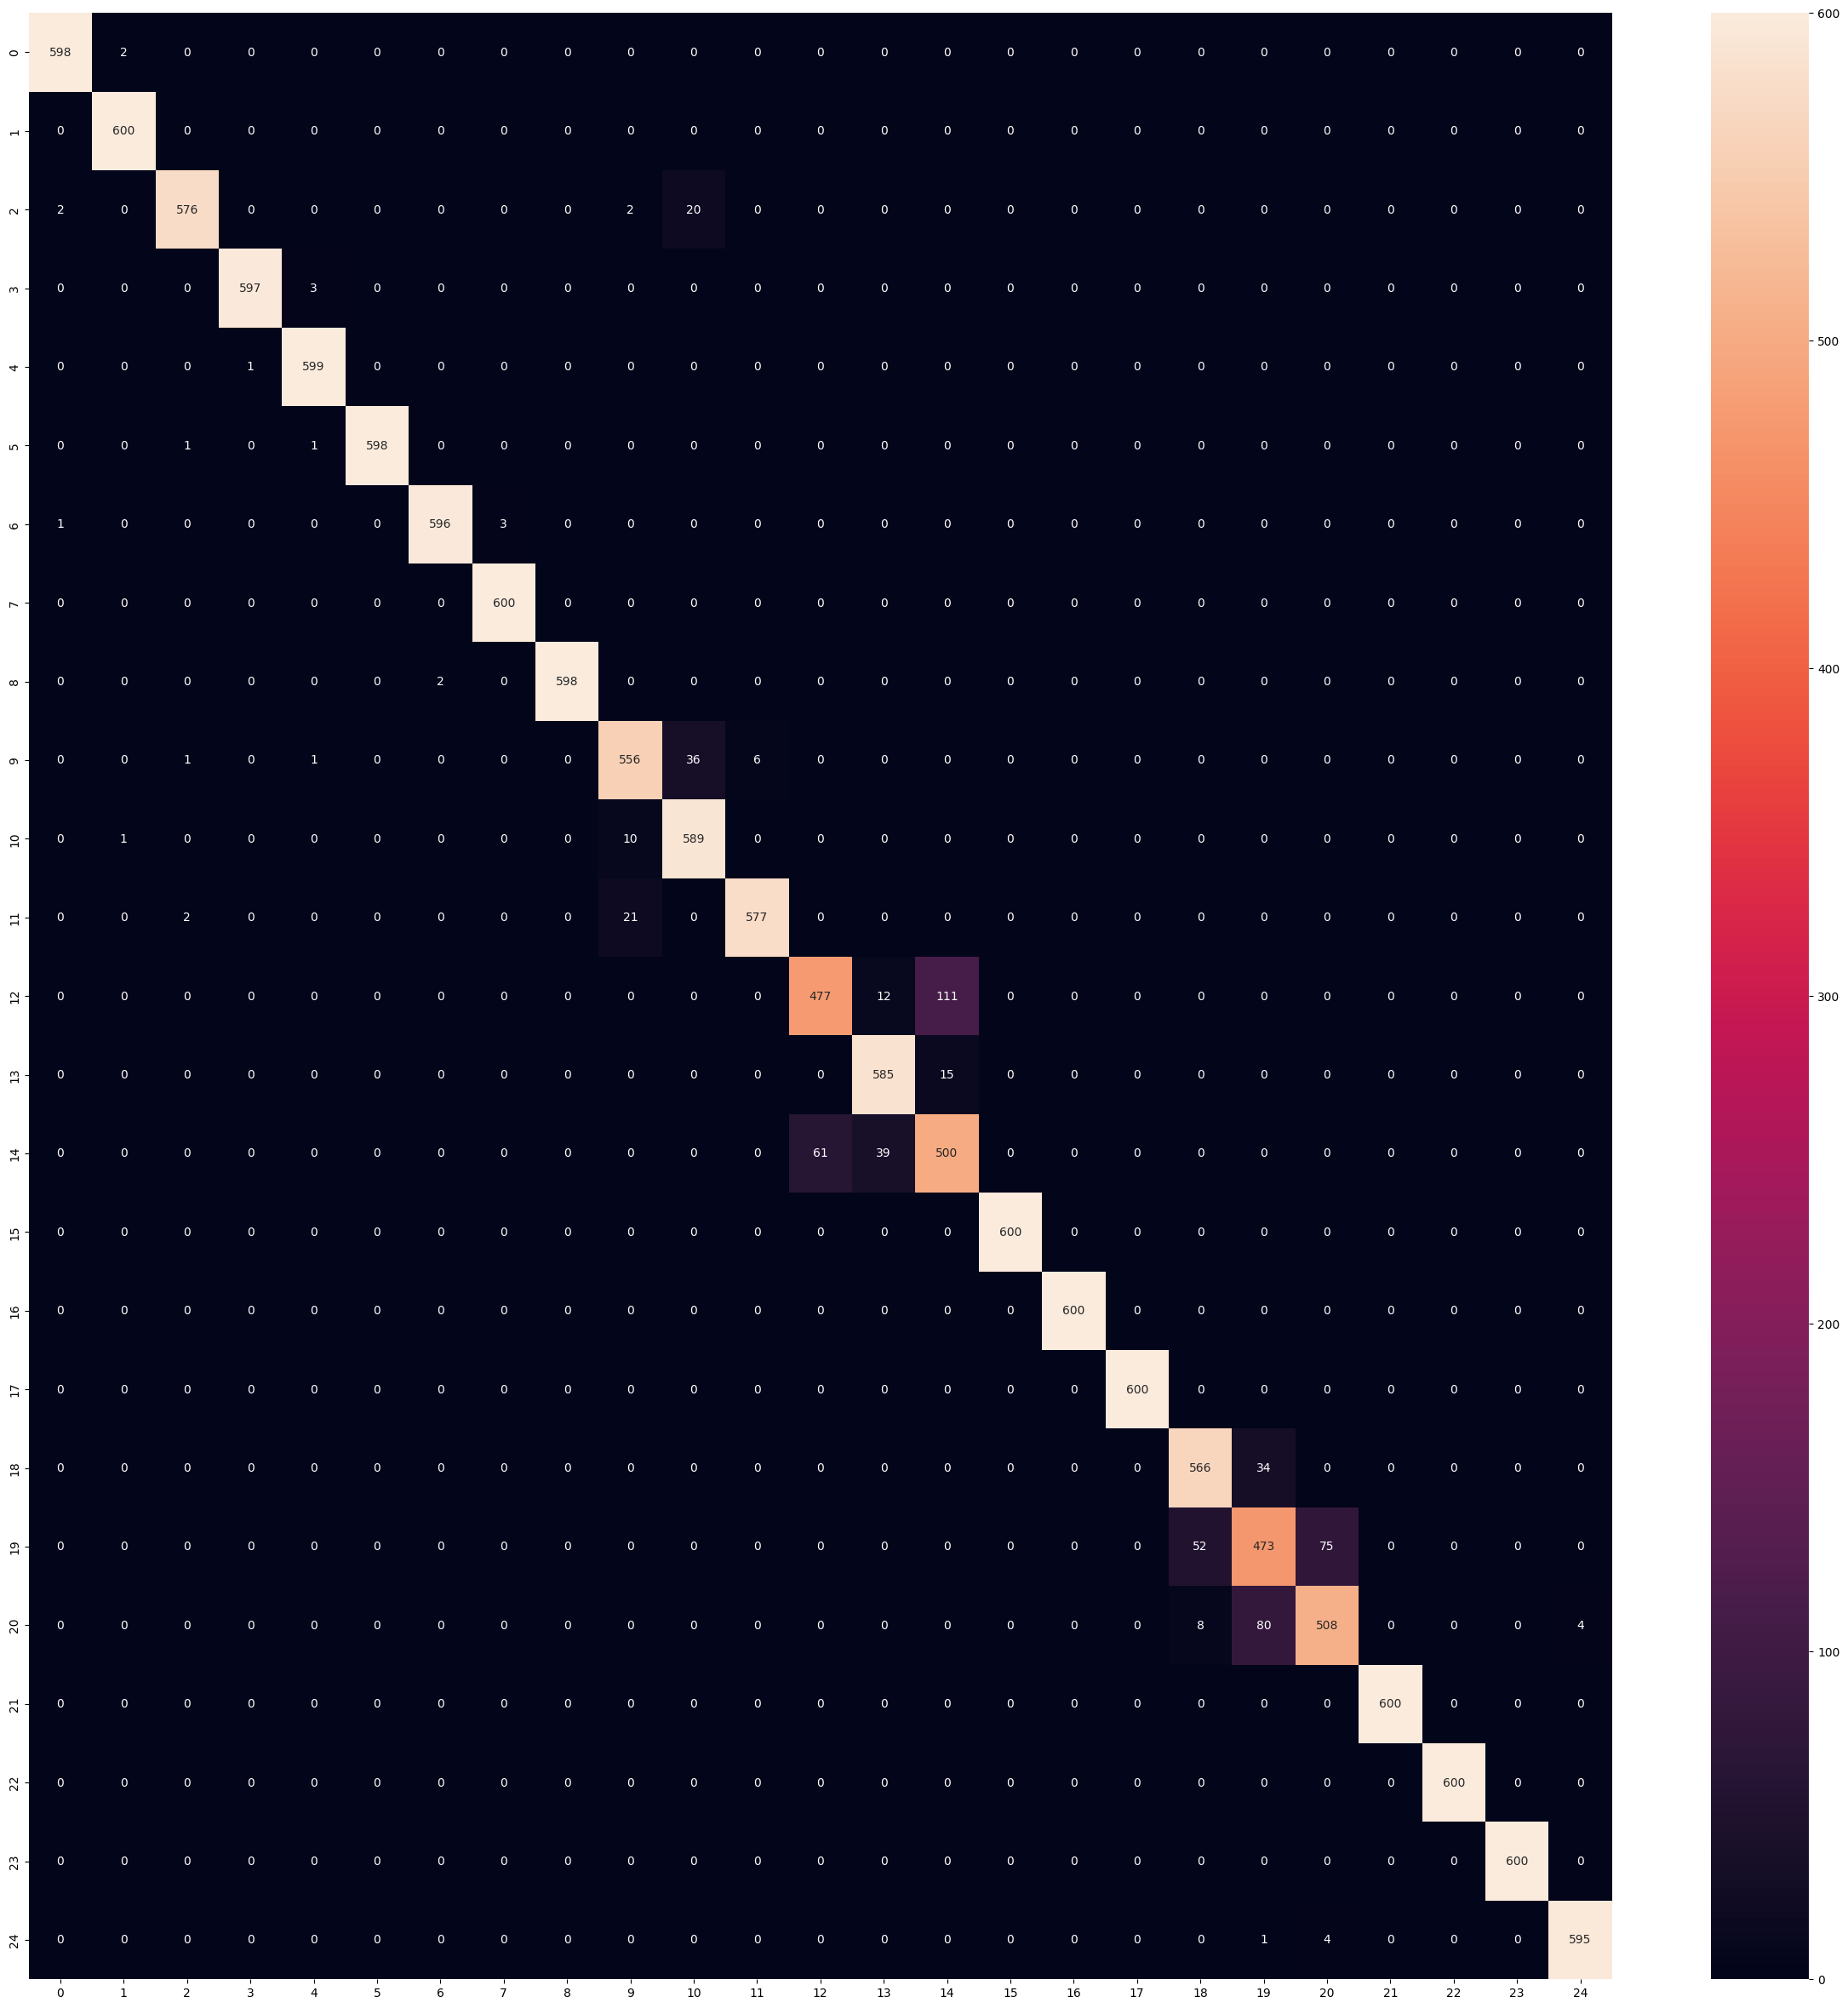

In [ ]:
plt.figure(figsize=(30,30))
sns.heatmap(cf_matrix, annot=True, fmt="");

END